# Import thư viện, Khởi tạo và Metric

In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class HybridDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.FloatTensor(X_seq)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

class HybridBiLSTMModel(nn.Module):
    def __init__(self, input_dim_per_phase, static_dim):
        super().__init__()

        self.hidden_dim = 128
        self.num_layers = 1
        self.dropout_p = 0.3
        self.num_classes = 3

        self.bilstm = nn.LSTM(
            input_size=input_dim_per_phase,
            hidden_size=self.hidden_dim,
            num_layers=self.num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(self.dropout_p)

        self.mlp = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.fc = nn.Linear(self.hidden_dim * 2 + 32, self.num_classes)

    def forward(self, x_seq, x_static):
        _, (h_n, _) = self.bilstm(x_seq)

        # h_n: (num_layers*2, batch, hidden_dim)
        h_forward = h_n[-2]
        h_backward = h_n[-1]

        h_concat = torch.cat((h_forward, h_backward), dim=1)
        h_concat = self.dropout(h_concat)

        static_out = self.mlp(x_static)

        combined = torch.cat((h_concat, static_out), dim=1)
        return self.fc(combined)

In [ ]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")

    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics

In [ ]:
def evaluate_hybrid_model(
    model,
    loader,
    device,
    dataset_name,
    output_dir="results"
):
    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)

            outputs = model(xb_seq, xb_static)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)

    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)

    # Plot CM
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


    # ===== Probability matrix =====
    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"

    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )
    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred

# Chuẩn bị dữ liệu + train

In [ ]:
def prepare_and_train_hybrid(train_path, val_path=None):
    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    # ===== Tách label =====
    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    # Lấy tất cả feature time-series của cả 4 phase
    phase_cols = [
        col for col in df_features.columns
        if any(f"_p{p}_" in col for p in ['1', '2', '3', '4'])
    ]

    phases_data = []

    for p in ['1', '2', '3', '4']:
        cols_p = [c for c in phase_cols if f"_p{p}_" in c]
        print(f"Phase {p}: {len(cols_p)} features")
        phases_data.append(df_features[cols_p].values)

    X_seq = np.stack(phases_data, axis=1)

    print(f"Time-series shape: {X_seq.shape}")


    # ====== Tách feature static ======
    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].values

    print(f"Static feature shape: {X_static.shape}")

    # ====== Chuẩn hóa ======
    scaler_seq = StandardScaler()
    N, T, F = X_seq.shape

    X_seq = scaler_seq.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)

    scaler_static = StandardScaler()
    X_static = scaler_static.fit_transform(X_static)

    # ===== Encode label =====
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Classes: {le.classes_}")

    # ===== Dataset =====
    dataset = HybridDataset(X_seq, X_static, y_enc)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    # ===== Model =====
    model = HybridBiLSTMModel(
        input_dim_per_phase=F,
        static_dim=X_static.shape[1]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ===== Train =====
    model.train()
    best_loss = float('inf')
    patience = 10
    wait = 0

    for epoch in range(50):
        epoch_loss = 0

        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            out = model(xb_seq, xb_static)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

        if epoch_loss < best_loss - 1e-4:
            best_loss = epoch_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    print("Training done")

    return model, scaler_seq, scaler_static, le, phase_cols, static_cols

In [ ]:
def run_and_report_hybrid(
    model,
    loader,
    device,
    dataset_name,
    version_name="HybridModel",
    phase="All"
):
    y_true, y_pred = evaluate_hybrid_model(
        model, loader, device, dataset_name
    )

    metrics = print_results(
        version_name=version_name,
        phase=phase,
        y_true=y_true,
        y_pred=y_pred
    )

    metrics_path = f"results/metrics_{dataset_name}.csv"
    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

    print(f"Saved metrics to: {metrics_path}")

    return metrics

# Chạy theo từng V

In [ ]:
base_path = "/kaggle/input/lo-dataset"

In [ ]:
import time

def run_experiment_hybrid(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train hybrid model =====
    start_train = time.perf_counter()

    model, scaler_seq, scaler_static, le, phase_cols, static_cols = \
        prepare_and_train_hybrid(train_path, val_path)

    time_build_model = time.perf_counter() - start_train

    results = []
    model.eval()

    with torch.no_grad():
        for phase, test_path in enumerate(test_files, 1):
            print(f"\n--- Test Phase {phase}: {test_path} ---")

            df_test = pd.read_csv(test_path)
            df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

            y_test = df_test['label_3'].values
            df_features = df_test.drop('label_3', axis=1)

            # ===== TÁCH TIME SERIES =====
            phases_data = []

            for p in ['1', '2', '3', '4']:
                cols_p = [c for c in phase_cols if f"_p{p}_" in c]
                phases_data.append(df_features[cols_p].values)

            X_seq = np.stack(phases_data, axis=1)

            # ===== Split static features =====
            X_static = df_features[static_cols].values

            # ===== Scaling =====
            N, T, F = X_seq.shape
            X_seq_scaled = scaler_seq.transform(
                X_seq.reshape(-1, F)
            ).reshape(N, T, F)

            X_static_scaled = scaler_static.transform(X_static)

            # ===== Convert to tensor =====
            X_seq_tensor = torch.FloatTensor(X_seq_scaled).to(device)
            X_static_tensor = torch.FloatTensor(X_static_scaled).to(device)

            # ===== Predict =====
            start_pred = time.perf_counter()

            outputs = model(X_seq_tensor, X_static_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            time_predict = time.perf_counter() - start_pred

            y_test_enc = le.transform(y_test)

            # ===== In metrics =====
            res = print_results(
                version_name=version_name,
                phase=phase,
                y_true=y_test_enc,
                y_pred=preds,
                time_build_model=time_build_model,
                time_predict=time_predict
            )

            # ===== Xuất confusion + probability =====
            run_and_report_hybrid(
                model=model,
                loader=DataLoader(
                    HybridDataset(X_seq_scaled, X_static_scaled, y_test_enc),
                    batch_size=256
                ),
                device=device,
                dataset_name=f"{version_name}_phase{phase}"
            )

            results.append(res)

    # ===== Tạo dataframe tổng hợp =====
    df = pd.DataFrame(results).round(10)

    # Đổi tên cột cho đúng
    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]

    df = df[ordered_cols]

    return df

## V0 (Raw)

In [ ]:
# base_path = "/kaggle/input/lo-dataset/Raw/Raw"

In [ ]:
#df_v0 = run_experiment_hybrid(
#    base_path=base_path,
#    train_file="train_raw.csv",
#    val_file="val.csv",
#    test_prefix="test",
#    version_name="V0 (Raw)"
#)

#df_v0

In [ ]:
#df_v0.to_csv("results_v0.csv", index=False)

## V1 (Median)

In [ ]:
base_path = "/kaggle/input/lo-dataset/Median/Median"


#####
Version: V1 (Median)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0084
Epoch 2: loss = 0.0054
Epoch 3: loss = 0.0050
Epoch 4: loss = 0.0046
Epoch 5: loss = 0.0043
Epoch 6: loss = 0.0041
Epoch 7: loss = 0.0039
Epoch 8: loss = 0.0038
Epoch 9: loss = 0.0036
Epoch 10: loss = 0.0035
Epoch 11: loss = 0.0033
Epoch 12: loss = 0.0032
Epoch 13: loss = 0.0032
Epoch 14: loss = 0.0031
Epoch 15: loss = 0.0030
Epoch 16: loss = 0.0030
Epoch 17: loss = 0.0029
Epoch 18: loss = 0.0029
Epoch 19: loss = 0.0028
Epoch 20: loss = 0.0028
Epoch 21: loss = 0.0027
Epoch 22: loss = 0.0027
Epoch 23: loss = 0.0026
Epoch 24: loss = 0.0026
Epoch 25: loss = 0.0025
Epoch 26: loss = 0.0025
Epoch 27: loss = 0.0025
Epoch 28: loss = 0.0025
Epoch 29: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V1 (Median),1,1540.731579,0.159962,0.995096,0.486251,0.754288,0.995602,0.486251,0.995096,0.505679,0.995012,0.482768,0.294719,0.294623,1.000000,0.125561,0.223108,0.354345,0.265359,0.335537,0.296350,0.578553,0.997505,0.997656,0.997580,0.548839
1,V1 (Median),2,1540.731579,0.157717,0.960590,0.602163,0.679474,0.996024,0.602163,0.960590,0.479656,0.977100,0.656552,0.158783,0.085826,1.000000,0.237668,0.384058,0.487512,0.039904,0.606612,0.074883,0.763877,0.998517,0.962210,0.980028,0.759973
2,V1 (Median),3,1540.731579,0.156026,0.996644,0.731683,0.790921,0.997507,0.731683,0.996644,0.726520,0.996922,0.793017,0.598635,0.592784,0.930435,0.479821,0.633136,0.692679,0.443309,0.717355,0.547980,0.845972,0.999019,0.997872,0.998445,0.851058
3,V1 (Median),4,1540.731579,0.156030,0.998512,0.849516,0.881668,0.998428,0.849516,0.998512,0.863874,0.998456,0.872981,0.780097,0.778887,0.864629,0.887892,0.876106,0.942218,0.781250,0.661157,0.716204,0.812919,0.999124,0.999499,0.999312,0.868592


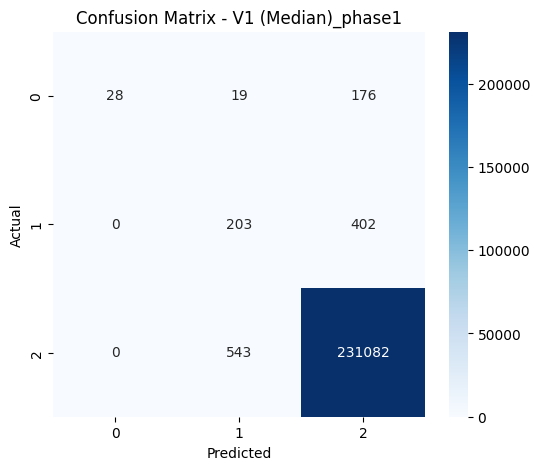

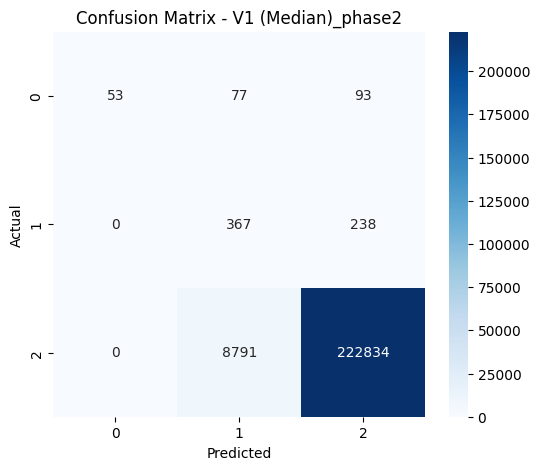

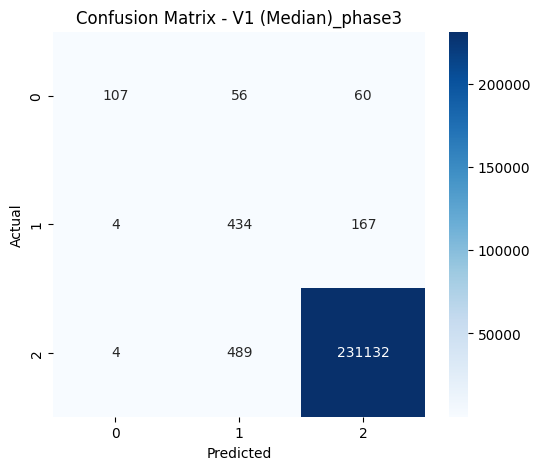

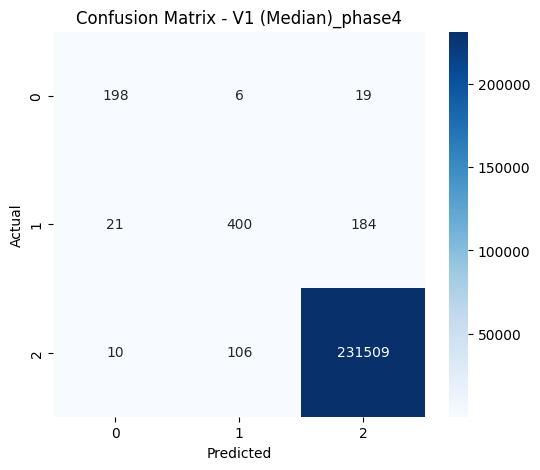

In [ ]:
df_v1 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V1 (Median)"
)

df_v1

In [ ]:
df_v1.to_csv("results_v1.csv", index=False)

## V2 (Median_CDSMOTE)


#####
Version: V2 (Median CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0467
Epoch 2: loss = 0.0223
Epoch 3: loss = 0.0186
Epoch 4: loss = 0.0166
Epoch 5: loss = 0.0153
Epoch 6: loss = 0.0145
Epoch 7: loss = 0.0138
Epoch 8: loss = 0.0133
Epoch 9: loss = 0.0129
Epoch 10: loss = 0.0125
Epoch 11: loss = 0.0122
Epoch 12: loss = 0.0119
Epoch 13: loss = 0.0116
Epoch 14: loss = 0.0115
Epoch 15: loss = 0.0112
Epoch 16: loss = 0.0111
Epoch 17: loss = 0.0109
Epoch 18: loss = 0.0109
Epoch 19: loss = 0.0108
Epoch 20: loss = 0.0106
Epoch 21: loss = 0.0105
Epoch 22: loss = 0.0104
Epoch 23: loss = 0.0103
Epoch 24: loss = 0.0102
Epoch 25: loss = 0.0102
Epoch 26: loss = 0.0101
Epoch 27: loss = 0.0100
Epoch 28: loss = 0.0099
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V2 (Median CDSMOTE),1,4273.123954,0.156130,0.996391,0.425497,0.702277,0.995578,0.425497,0.996391,0.451374,0.995123,0.312603,0.216775,0.165298,0.360000,0.242152,0.289544,0.491988,0.750000,0.034711,0.066351,0.186305,0.996831,0.999629,0.998228,0.333271
1,V2 (Median CDSMOTE),2,4273.123954,0.156165,0.996739,0.471345,0.827782,0.996313,0.471345,0.996739,0.520166,0.995568,0.388848,0.320843,0.242864,0.600000,0.349776,0.441926,0.591352,0.886364,0.064463,0.120185,0.253893,0.996982,0.999797,0.998388,0.391600
2,V2 (Median CDSMOTE),3,4273.123954,0.156109,0.997643,0.662863,0.889929,0.997284,0.662863,0.997643,0.733717,0.997145,0.662771,0.589873,0.552229,0.876404,0.699552,0.778055,0.836352,0.795455,0.289256,0.424242,0.537773,0.997927,0.999780,0.998853,0.647294
3,V2 (Median CDSMOTE),4,4273.123954,0.156375,0.996653,0.892701,0.663189,0.997762,0.892701,0.996653,0.747107,0.997071,0.920089,0.659562,0.640548,0.473810,0.892377,0.618974,0.944207,0.516234,0.788430,0.623937,0.887079,0.999524,0.997297,0.998409,0.929950


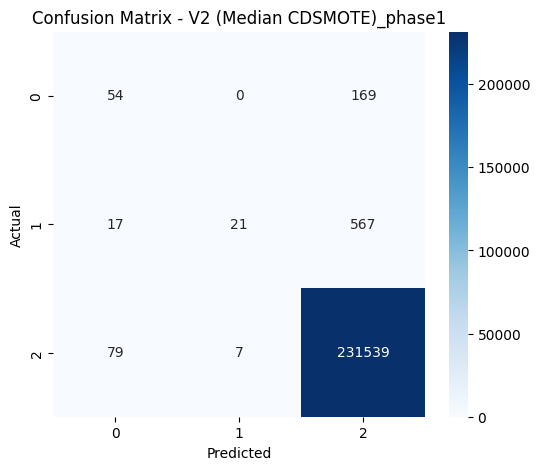

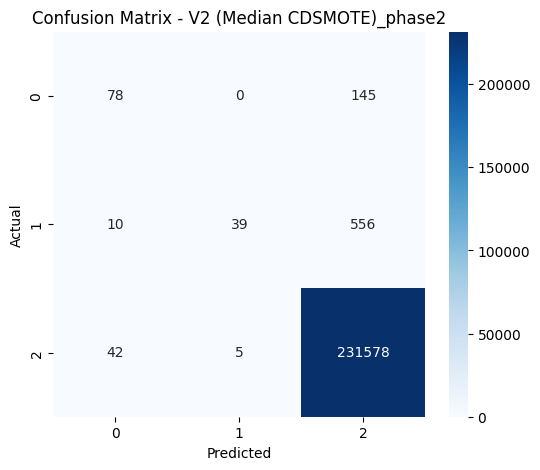

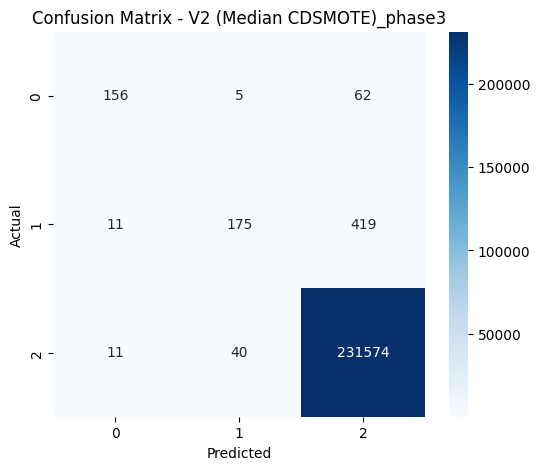

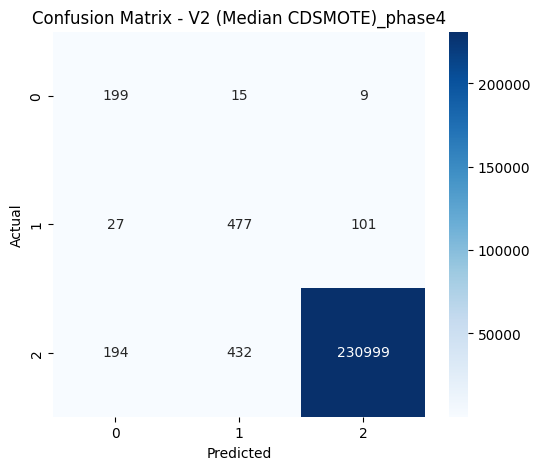

In [ ]:
df_v2 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V2 (Median CDSMOTE)"
)

df_v2

In [ ]:
df_v2.to_csv("results_v2.csv", index=False)

## V3 (Median SASMOTE)


#####
Version: V3 (Median SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0466
Epoch 2: loss = 0.0222
Epoch 3: loss = 0.0184
Epoch 4: loss = 0.0164
Epoch 5: loss = 0.0151
Epoch 6: loss = 0.0143
Epoch 7: loss = 0.0135
Epoch 8: loss = 0.0130
Epoch 9: loss = 0.0126
Epoch 10: loss = 0.0123
Epoch 11: loss = 0.0120
Epoch 12: loss = 0.0118
Epoch 13: loss = 0.0115
Epoch 14: loss = 0.0113
Epoch 15: loss = 0.0111
Epoch 16: loss = 0.0110
Epoch 17: loss = 0.0108
Epoch 18: loss = 0.0107
Epoch 19: loss = 0.0106
Epoch 20: loss = 0.0104
Epoch 21: loss = 0.0104
Epoch 22: loss = 0.0102
Epoch 23: loss = 0.0102
Epoch 24: loss = 0.0101
Epoch 25: loss = 0.0100
Epoch 26: loss = 0.0099
Epoch 27: loss = 0.0098
Epoch 28: loss = 0.0099
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V3 (Median SASMOTE),1,4483.554262,0.156118,0.995504,0.459200,0.507958,0.994501,0.459200,0.995504,0.470986,0.994905,0.419864,0.214974,0.207952,0.232932,0.260090,0.245763,0.509780,0.293878,0.119008,0.169412,0.344847,0.997064,0.998502,0.997782,0.421035
1,V3 (Median SASMOTE),2,4483.554262,0.156081,0.996395,0.495779,0.759650,0.995581,0.495779,0.996395,0.565441,0.995766,0.490712,0.335745,0.314057,0.915493,0.291480,0.442177,0.539882,0.366154,0.196694,0.255914,0.443305,0.997302,0.999162,0.998232,0.493718
2,V3 (Median SASMOTE),3,4483.554262,0.156125,0.991719,0.668118,0.602809,0.995864,0.668118,0.991719,0.608271,0.993581,0.718558,0.334949,0.305866,0.648649,0.538117,0.588235,0.733462,0.161400,0.472727,0.240639,0.685345,0.998377,0.993511,0.995938,0.738073
3,V3 (Median SASMOTE),4,4483.554262,0.155919,0.996447,0.881151,0.651442,0.997714,0.881151,0.996447,0.735422,0.996927,0.915667,0.649174,0.627433,0.465347,0.843049,0.599681,0.917750,0.489426,0.803306,0.608260,0.895293,0.999554,0.997099,0.998325,0.934379


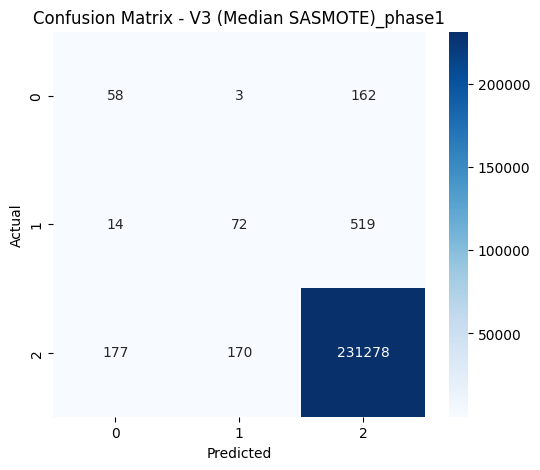

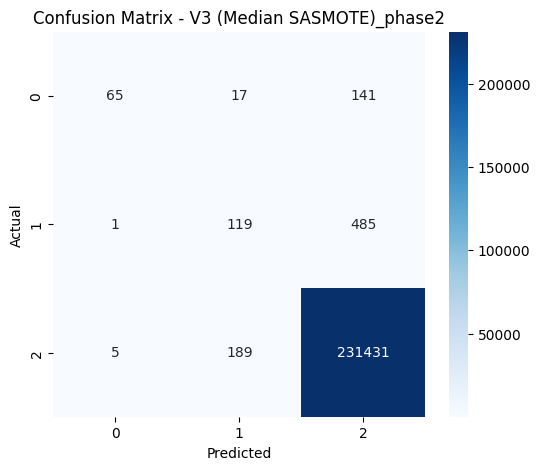

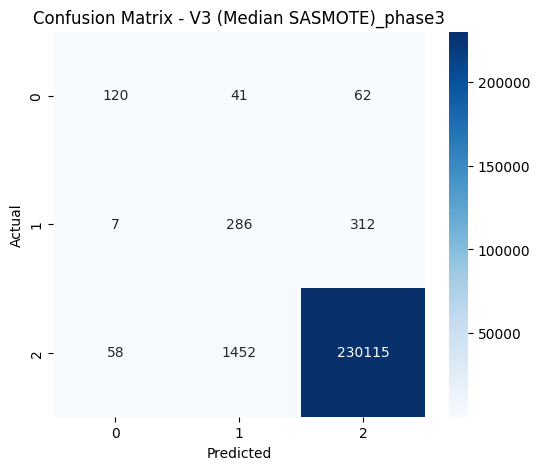

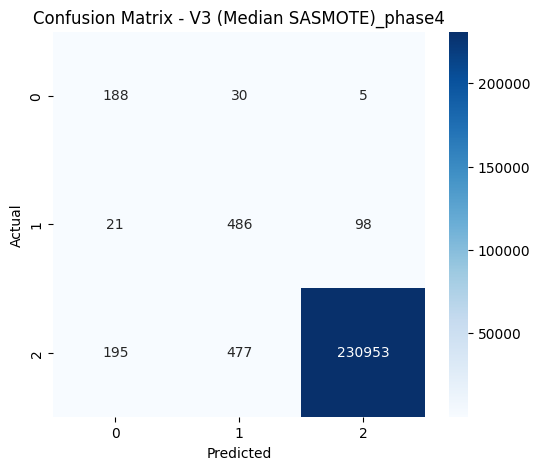

In [ ]:
df_v3 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V3 (Median SASMOTE)"
)

df_v3

In [ ]:
df_v3.to_csv("results_v3.csv", index=False)

## V4 (Median RadiusSMOTE)


#####
Version: V4 (Median RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0386
Epoch 2: loss = 0.0165
Epoch 3: loss = 0.0138
Epoch 4: loss = 0.0125
Epoch 5: loss = 0.0115
Epoch 6: loss = 0.0109
Epoch 7: loss = 0.0104
Epoch 8: loss = 0.0099
Epoch 9: loss = 0.0096
Epoch 10: loss = 0.0094
Epoch 11: loss = 0.0090
Epoch 12: loss = 0.0088
Epoch 13: loss = 0.0087
Epoch 14: loss = 0.0085
Epoch 15: loss = 0.0084
Epoch 16: loss = 0.0083
Epoch 17: loss = 0.0081
Epoch 18: loss = 0.0080
Epoch 19: loss = 0.0080
Epoch 20: loss = 0.0079
Epoch 21: loss = 0.0077
Epoch 22: loss = 0.0077
Epoch 23: loss = 0.0077
Epoch 24: loss = 0.0076
Epoch 25: loss = 0.0075
Epoch 26: loss = 0.0075
Epoch 27: loss = 0.0074
Epoch 28: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V4 (Median RadiusSMOTE),1,4554.384929,0.156318,0.996580,0.403816,0.846651,0.995765,0.403816,0.996580,0.446504,0.995492,0.319620,0.283265,0.222728,1.000000,0.044843,0.085837,0.211762,0.543011,0.166942,0.255373,0.408511,0.996943,0.999663,0.998301,0.377444
1,V4 (Median RadiusSMOTE),2,4554.384929,0.156443,0.996799,0.565024,0.690478,0.996213,0.565024,0.996799,0.613397,0.996411,0.597808,0.456833,0.443990,0.490798,0.358744,0.414508,0.598846,0.582857,0.337190,0.427225,0.580498,0.997780,0.999137,0.998458,0.614567
2,V4 (Median RadiusSMOTE),3,4554.384929,0.156204,0.997122,0.700091,0.727629,0.997036,0.700091,0.997122,0.713308,0.997077,0.751950,0.583055,0.582794,0.645320,0.587444,0.615023,0.766330,0.538995,0.514050,0.526227,0.716561,0.998571,0.998778,0.998675,0.774279
3,V4 (Median RadiusSMOTE),4,4554.384929,0.156369,0.997212,0.826669,0.698026,0.997711,0.826669,0.997212,0.752157,0.997419,0.872306,0.666249,0.660171,0.544892,0.789238,0.644689,0.888109,0.549869,0.692562,0.613021,0.831587,0.999317,0.998208,0.998762,0.898737


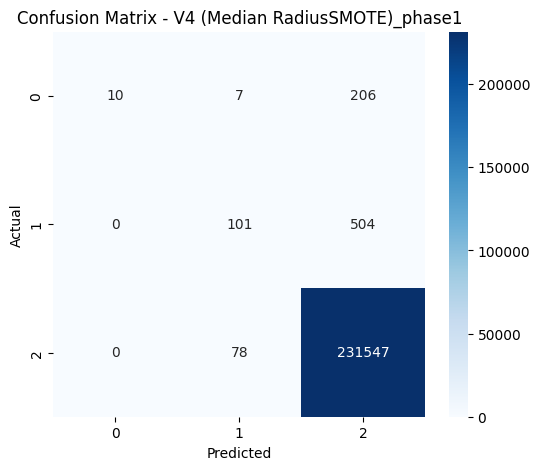

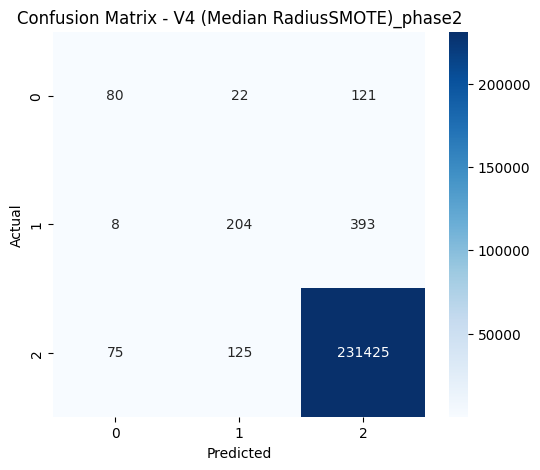

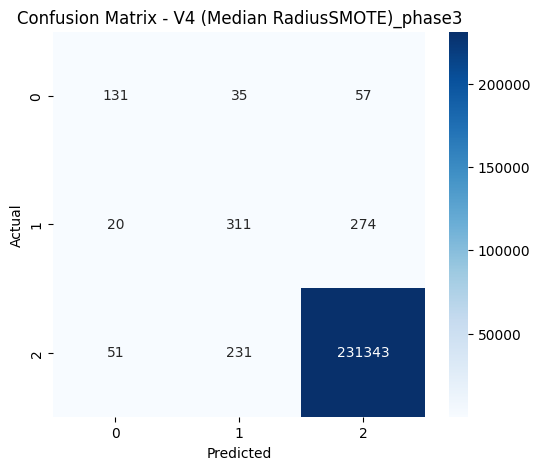

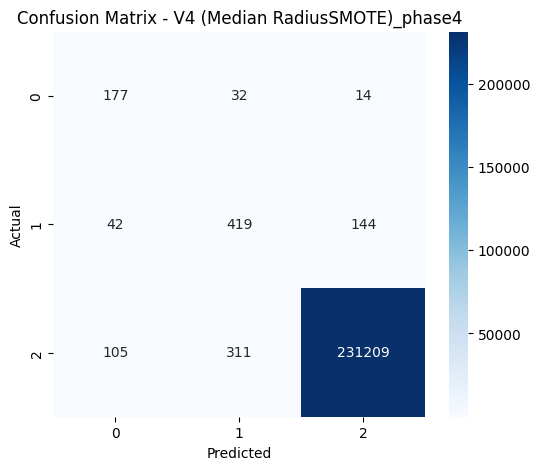

In [ ]:
df_v4 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V4 (Median RadiusSMOTE)"
)

df_v4

In [ ]:
df_v4.to_csv("results_v4.csv", index=False)

## V5 (Mean)

In [ ]:
base_path = "/kaggle/input/lo-dataset/Mean/Mean"


#####
Version: V5 (Mean)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0081
Epoch 2: loss = 0.0054
Epoch 3: loss = 0.0050
Epoch 4: loss = 0.0047
Epoch 5: loss = 0.0044
Epoch 6: loss = 0.0042
Epoch 7: loss = 0.0040
Epoch 8: loss = 0.0038
Epoch 9: loss = 0.0037
Epoch 10: loss = 0.0035
Epoch 11: loss = 0.0034
Epoch 12: loss = 0.0033
Epoch 13: loss = 0.0032
Epoch 14: loss = 0.0031
Epoch 15: loss = 0.0031
Epoch 16: loss = 0.0030
Epoch 17: loss = 0.0030
Epoch 18: loss = 0.0029
Epoch 19: loss = 0.0029
Epoch 20: loss = 0.0028
Epoch 21: loss = 0.0028
Epoch 22: loss = 0.0027
Epoch 23: loss = 0.0026
Epoch 24: loss = 0.0027
Epoch 25: loss = 0.0026
Epoch 26: loss = 0.0026
Epoch 27: loss = 0.0025
Epoch 28: loss = 0.0025
Epoch 29: loss = 0.0025
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V5 (Mean),1,1656.235777,0.156320,0.996743,0.440558,0.843588,0.996013,0.440558,0.996743,0.502113,0.995836,0.409895,0.351014,0.295495,0.961538,0.112108,0.200803,0.334824,0.572072,0.209917,0.307134,0.458074,0.997153,0.999650,0.998400,0.449021
1,V5 (Mean),2,1656.235777,0.156149,0.997126,0.561513,0.761107,0.996545,0.561513,0.997126,0.630817,0.996670,0.595442,0.496291,0.472553,0.630252,0.336323,0.438596,0.579879,0.655280,0.348760,0.455232,0.590418,0.997789,0.999456,0.998622,0.616626
2,V5 (Mean),3,1656.235777,0.156397,0.997617,0.712333,0.839799,0.997539,0.712333,0.997617,0.761596,0.997536,0.764516,0.641519,0.639750,0.911765,0.556054,0.690808,0.745671,0.608997,0.581818,0.595097,0.762398,0.998636,0.999128,0.998882,0.786014
3,V5 (Mean),4,1656.235777,0.155982,0.998520,0.849591,0.882045,0.998452,0.849591,0.998520,0.865020,0.998480,0.876953,0.783393,0.782647,0.885845,0.869955,0.877828,0.932664,0.761111,0.679339,0.717904,0.823991,0.999180,0.999478,0.999329,0.877570


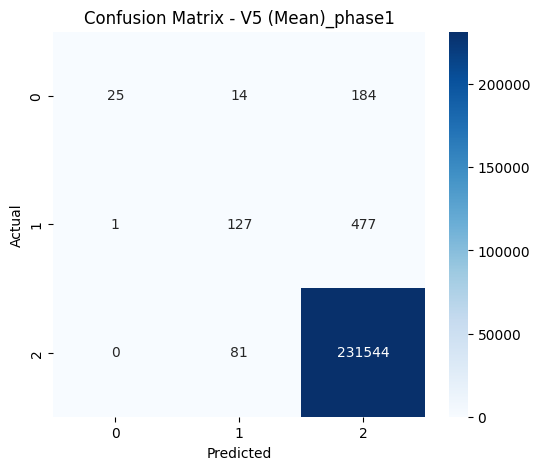

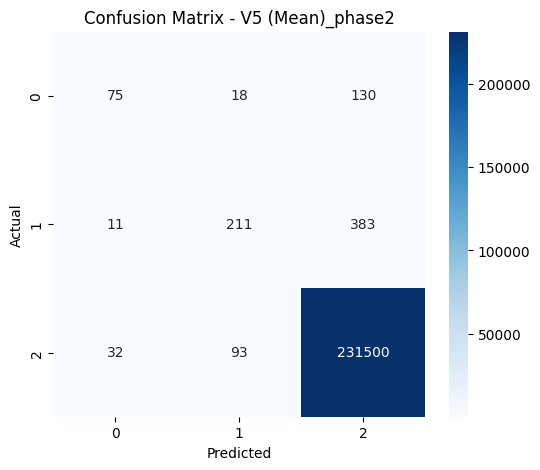

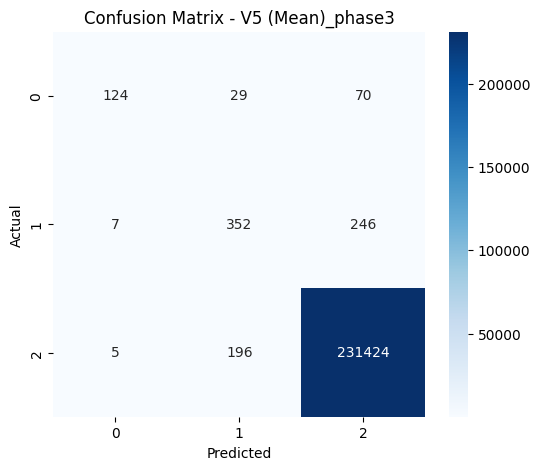

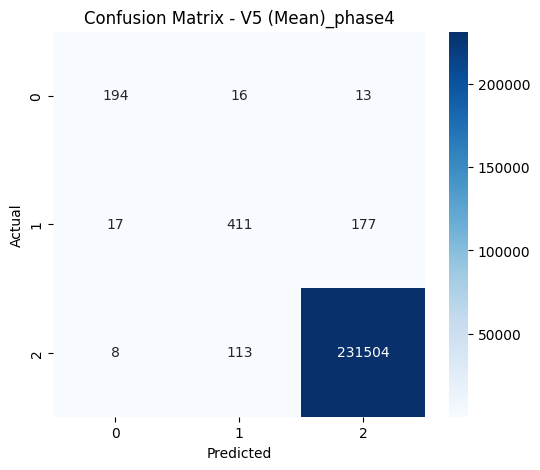

In [ ]:
df_v5 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V5 (Mean)"
)

df_v5

In [ ]:
df_v5.to_csv("results_v5.csv", index=False)

## V6 (Mean CDSMOTE)


#####
Version: V6 (Mean CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0442
Epoch 2: loss = 0.0195
Epoch 3: loss = 0.0157
Epoch 4: loss = 0.0139
Epoch 5: loss = 0.0128
Epoch 6: loss = 0.0120
Epoch 7: loss = 0.0114
Epoch 8: loss = 0.0109
Epoch 9: loss = 0.0106
Epoch 10: loss = 0.0102
Epoch 11: loss = 0.0099
Epoch 12: loss = 0.0097
Epoch 13: loss = 0.0095
Epoch 14: loss = 0.0093
Epoch 15: loss = 0.0091
Epoch 16: loss = 0.0090
Epoch 17: loss = 0.0089
Epoch 18: loss = 0.0088
Epoch 19: loss = 0.0087
Epoch 20: loss = 0.0087
Epoch 21: loss = 0.0084
Epoch 22: loss = 0.0084
Epoch 23: loss = 0.0083
Epoch 24: loss = 0.0083
Epoch 25: loss = 0.0082
Epoch 26: loss = 0.0082
Epoch 27: loss = 0.0081
Epoch 28: loss = 0.0081
Epoch 29:

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V6 (Mean CDSMOTE),1,4623.18521,0.156177,0.996330,0.420386,0.635947,0.995089,0.420386,0.996330,0.462017,0.995444,0.366357,0.276257,0.244589,0.484848,0.071749,0.125000,0.267850,0.425926,0.190083,0.262857,0.435839,0.997067,0.999326,0.998195,0.421209
1,V6 (Mean CDSMOTE),2,4623.18521,0.156061,0.996610,0.539216,0.670977,0.995858,0.539216,0.996610,0.584473,0.996082,0.552719,0.400202,0.382210,0.471591,0.372197,0.416040,0.609958,0.543796,0.246281,0.339022,0.496133,0.997543,0.999171,0.998356,0.557975
2,V6 (Mean CDSMOTE),3,4623.18521,0.156004,0.997057,0.625728,0.737032,0.996508,0.625728,0.997057,0.662311,0.996634,0.641673,0.500272,0.485039,0.608295,0.591928,0.600000,0.769228,0.604895,0.285950,0.388328,0.534613,0.997905,0.999305,0.998604,0.642461
3,V6 (Mean CDSMOTE),4,4623.18521,0.156069,0.996877,0.824598,0.682018,0.997531,0.824598,0.996877,0.740971,0.997147,0.867869,0.638702,0.630439,0.544343,0.798206,0.647273,0.893137,0.502451,0.677686,0.577058,0.822496,0.999261,0.997902,0.998581,0.889839


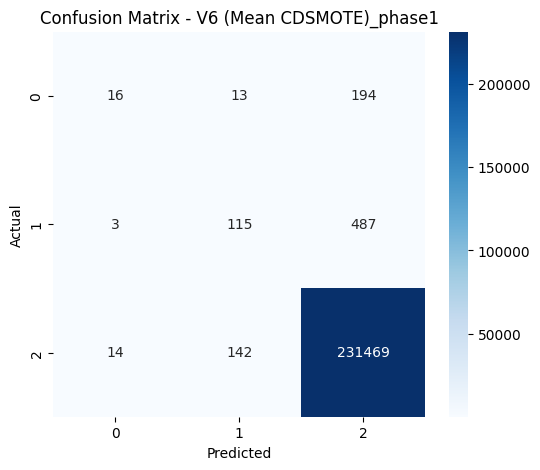

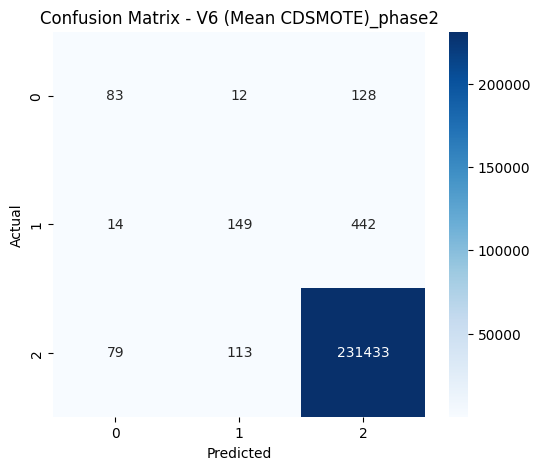

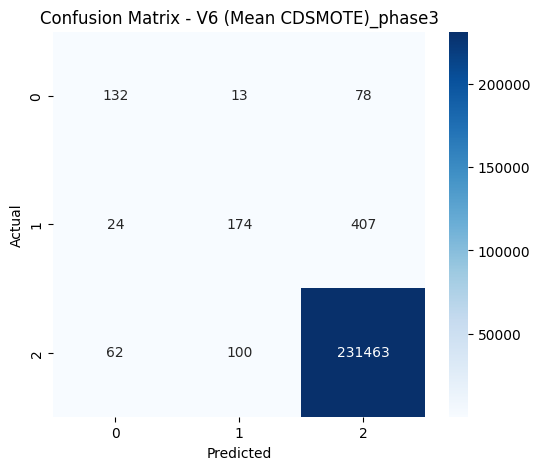

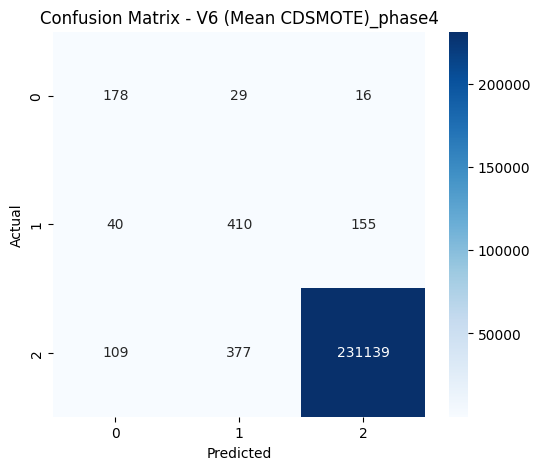

In [ ]:
df_v6 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V6 (Mean CDSMOTE)"
)

df_v6

In [ ]:
df_v6.to_csv("results_v6.csv", index=False)

## V7 (Mean SASMOTE)


#####
Version: V7 (Mean SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0488
Epoch 2: loss = 0.0253
Epoch 3: loss = 0.0213
Epoch 4: loss = 0.0190
Epoch 5: loss = 0.0175
Epoch 6: loss = 0.0164
Epoch 7: loss = 0.0156
Epoch 8: loss = 0.0151
Epoch 9: loss = 0.0146
Epoch 10: loss = 0.0142
Epoch 11: loss = 0.0138
Epoch 12: loss = 0.0135
Epoch 13: loss = 0.0131
Epoch 14: loss = 0.0130
Epoch 15: loss = 0.0128
Epoch 16: loss = 0.0126
Epoch 17: loss = 0.0124
Epoch 18: loss = 0.0122
Epoch 19: loss = 0.0121
Epoch 20: loss = 0.0120
Epoch 21: loss = 0.0120
Epoch 22: loss = 0.0118
Epoch 23: loss = 0.0117
Epoch 24: loss = 0.0116
Epoch 25: loss = 0.0115
Epoch 26: loss = 0.0114
Epoch 27: loss = 0.0114
Epoch 28: loss = 0.0113
Epoch 29: los

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V7 (Mean SASMOTE),1,4548.413986,0.155776,0.995100,0.476245,0.391704,0.993623,0.476245,0.995100,0.416530,0.994311,0.000000,0.169848,0.165908,0.178108,0.430493,0.251969,0.655494,0.000000,0.000000,0.000000,0.000000,0.997003,0.998243,0.997623,0.400432
1,V7 (Mean SASMOTE),2,4548.413986,0.155854,0.996718,0.472772,0.772880,0.995815,0.472772,0.996718,0.506445,0.995396,0.309811,0.306981,0.224020,0.629371,0.403587,0.491803,0.635213,0.692308,0.014876,0.029126,0.121966,0.996961,0.999853,0.998405,0.383825
2,V7 (Mean SASMOTE),3,4548.413986,0.155782,0.997204,0.560275,0.846367,0.996576,0.560275,0.997204,0.634157,0.996408,0.540388,0.474752,0.412035,0.827338,0.515695,0.635359,0.718082,0.714286,0.165289,0.268456,0.406523,0.997476,0.999840,0.998657,0.540577
3,V7 (Mean SASMOTE),4,4548.413986,0.155854,0.995724,0.893561,0.622914,0.997561,0.893561,0.995724,0.714785,0.996420,0.923555,0.617225,0.586002,0.438202,0.874439,0.583832,0.934611,0.430959,0.809917,0.562572,0.898697,0.999580,0.996326,0.997950,0.937873


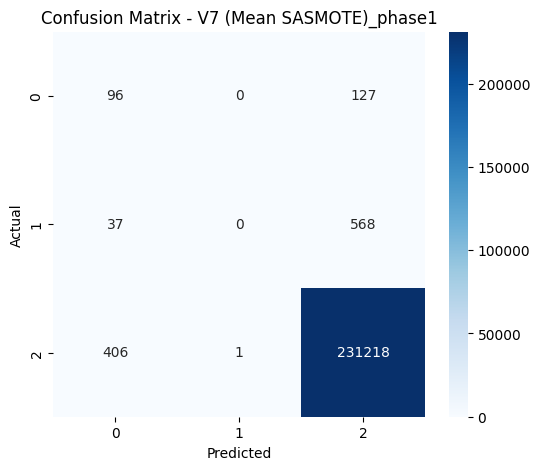

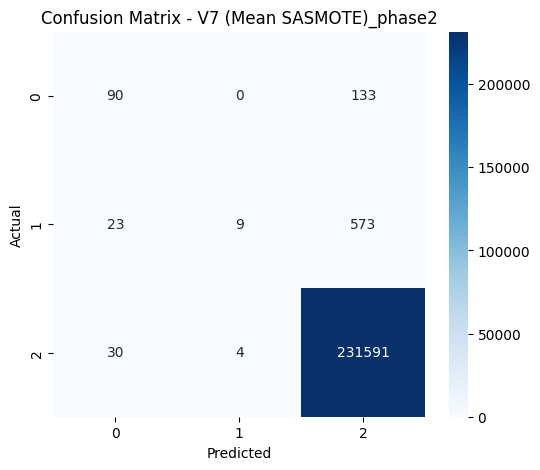

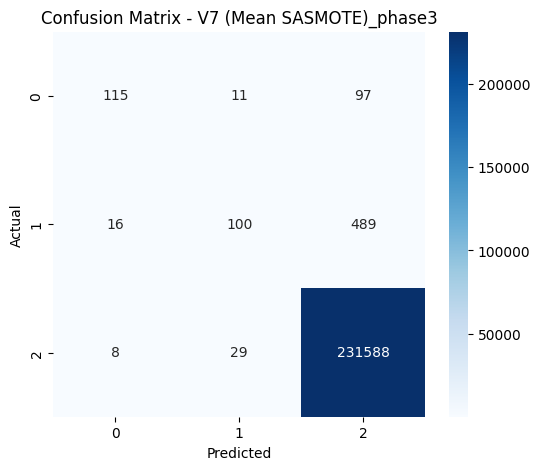

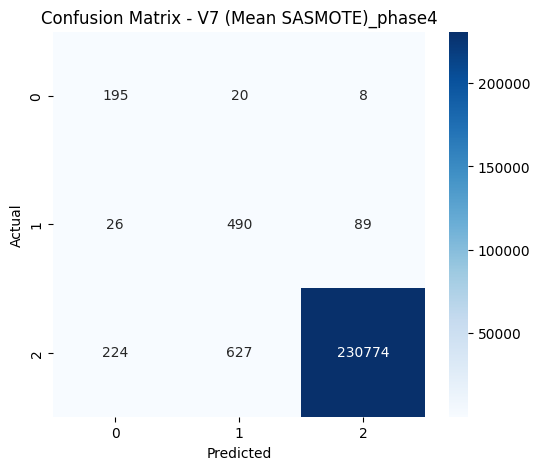

In [ ]:
df_v7 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V7 (Mean SASMOTE)"
)

df_v7

In [ ]:
df_v7.to_csv("results_v7.csv", index=False)

## V8 (Mean RadiusSMOTE)


#####
Version: V8 (Mean RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0438
Epoch 2: loss = 0.0196
Epoch 3: loss = 0.0156
Epoch 4: loss = 0.0139
Epoch 5: loss = 0.0128
Epoch 6: loss = 0.0120
Epoch 7: loss = 0.0115
Epoch 8: loss = 0.0110
Epoch 9: loss = 0.0107
Epoch 10: loss = 0.0103
Epoch 11: loss = 0.0102
Epoch 12: loss = 0.0098
Epoch 13: loss = 0.0097
Epoch 14: loss = 0.0095
Epoch 15: loss = 0.0093
Epoch 16: loss = 0.0093
Epoch 17: loss = 0.0091
Epoch 18: loss = 0.0090
Epoch 19: loss = 0.0088
Epoch 20: loss = 0.0087
Epoch 21: loss = 0.0086
Epoch 22: loss = 0.0086
Epoch 23: loss = 0.0085
Epoch 24: loss = 0.0084
Epoch 25: loss = 0.0083
Epoch 26: loss = 0.0083
Epoch 27: loss = 0.0082
Epoch 28: loss = 0.0082
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V8 (Mean RadiusSMOTE),1,4115.694271,0.155913,0.995573,0.535572,0.550419,0.995326,0.535572,0.995573,0.530048,0.995372,0.551209,0.322708,0.321376,0.239193,0.372197,0.291228,0.609733,0.414493,0.236364,0.301053,0.485961,0.997571,0.998157,0.997864,0.565206
1,V8 (Mean RadiusSMOTE),2,4115.694271,0.155878,0.996128,0.627615,0.621291,0.996137,0.627615,0.996128,0.598103,0.995994,0.648234,0.424281,0.423496,0.319613,0.591928,0.415094,0.768903,0.546296,0.292562,0.381055,0.540718,0.997963,0.998355,0.998159,0.655168
2,V8 (Mean RadiusSMOTE),3,4115.694271,0.155824,0.991706,0.796432,0.512002,0.996829,0.796432,0.991706,0.563039,0.993978,0.842283,0.423587,0.374516,0.130435,0.847534,0.226077,0.918115,0.406365,0.548760,0.466948,0.740008,0.999205,0.993002,0.996094,0.879508
3,V8 (Mean RadiusSMOTE),4,4115.694271,0.155960,0.996765,0.821717,0.675244,0.997578,0.821717,0.996765,0.735376,0.997096,0.871999,0.639784,0.628658,0.543689,0.753363,0.631579,0.867701,0.482682,0.714050,0.576000,0.844170,0.999360,0.997738,0.998548,0.905206


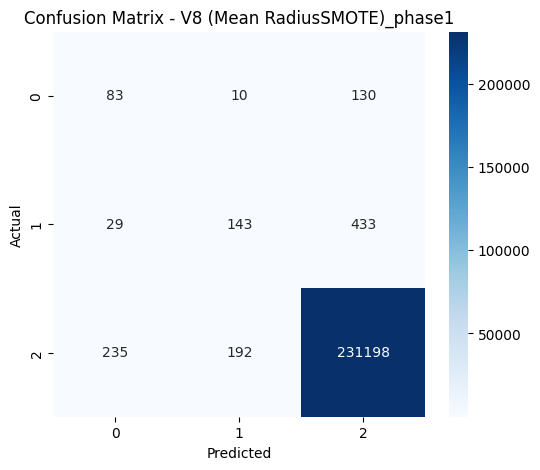

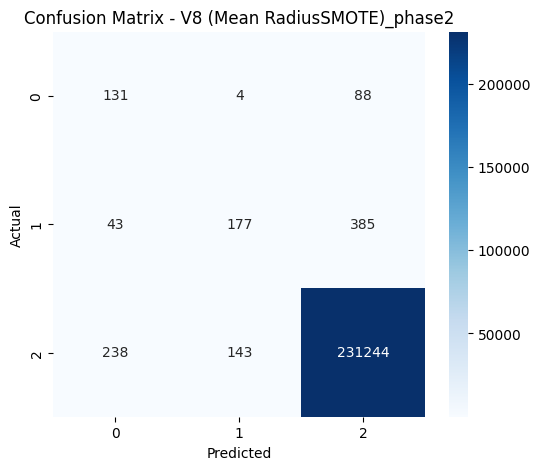

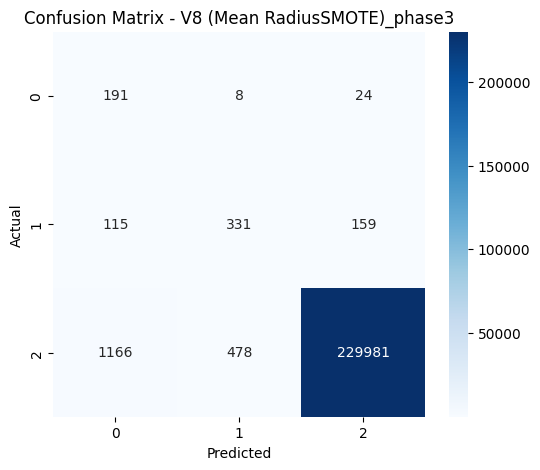

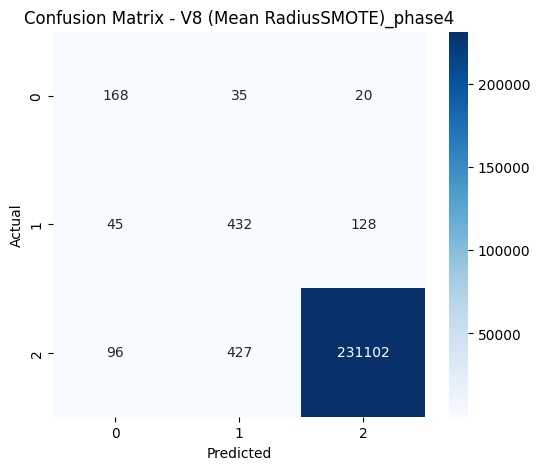

In [ ]:
df_v8 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V8 (Mean RadiusSMOTE)"
)

df_v8

In [ ]:
df_v8.to_csv("results_v8.csv", index=False)

## V9 (MissForest)

In [ ]:
base_path = "/kaggle/input/lo-dataset/Extra_trees/Extra_trees"


#####
Version: V9 (MissForest)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0089
Epoch 2: loss = 0.0054
Epoch 3: loss = 0.0047
Epoch 4: loss = 0.0043
Epoch 5: loss = 0.0039
Epoch 6: loss = 0.0036
Epoch 7: loss = 0.0034
Epoch 8: loss = 0.0032
Epoch 9: loss = 0.0030
Epoch 10: loss = 0.0028
Epoch 11: loss = 0.0027
Epoch 12: loss = 0.0026
Epoch 13: loss = 0.0025
Epoch 14: loss = 0.0024
Epoch 15: loss = 0.0023
Epoch 16: loss = 0.0022
Epoch 17: loss = 0.0022
Epoch 18: loss = 0.0021
Epoch 19: loss = 0.0021
Epoch 20: loss = 0.0020
Epoch 21: loss = 0.0020
Epoch 22: loss = 0.0020
Epoch 23: loss = 0.0019
Epoch 24: loss = 0.0020
Epoch 25: loss = 0.0019
Epoch 26: loss = 0.0018
Epoch 27: loss = 0.0018
Epoch 28: loss = 0.0018
Epoch 29

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V9 (MissForest),1,1607.035101,0.172938,0.996300,0.387703,0.667878,0.994923,0.387703,0.996300,0.417635,0.995200,0.285434,0.223725,0.183765,0.636364,0.031390,0.059829,0.177171,0.370370,0.132231,0.194884,0.363530,0.996900,0.999486,0.998191,0.361065
1,V9 (MissForest),2,1607.035101,0.157610,0.996292,0.461780,0.740677,0.995546,0.461780,0.996292,0.516296,0.995645,0.456174,0.322197,0.303451,0.857143,0.161435,0.271698,0.401785,0.367568,0.224793,0.278974,0.473884,0.997319,0.999111,0.998214,0.498569
2,V9 (MissForest),3,1607.035101,0.155991,0.996447,0.721619,0.635409,0.996899,0.721619,0.996447,0.667300,0.996640,0.772945,0.547307,0.545031,0.355091,0.609865,0.448845,0.780523,0.552459,0.557025,0.554733,0.745901,0.998678,0.997967,0.998322,0.793192
3,V9 (MissForest),4,1607.035101,0.155923,0.998598,0.840334,0.883417,0.998531,0.840334,0.998598,0.860889,0.998558,0.875038,0.794034,0.793109,0.867299,0.820628,0.843318,0.905830,0.783734,0.700826,0.739965,0.836943,0.999219,0.999547,0.999383,0.883768


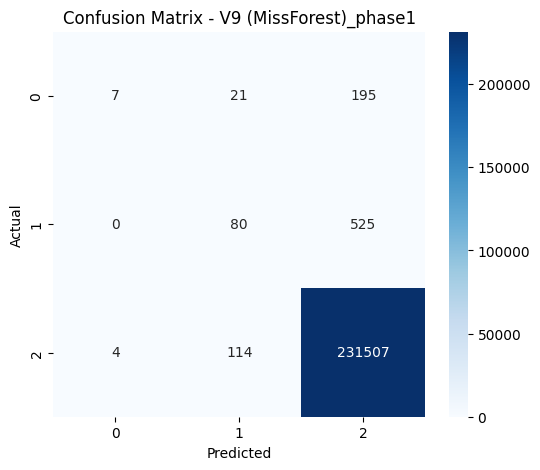

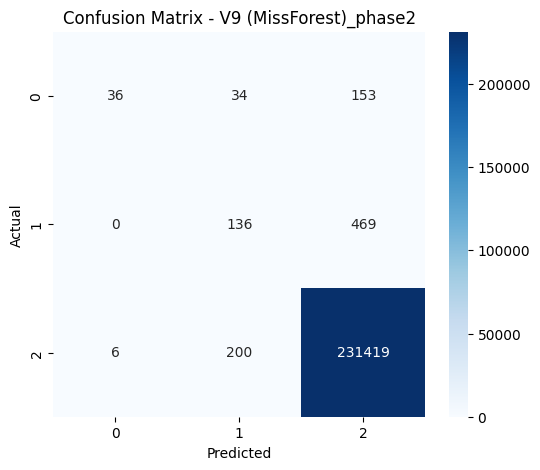

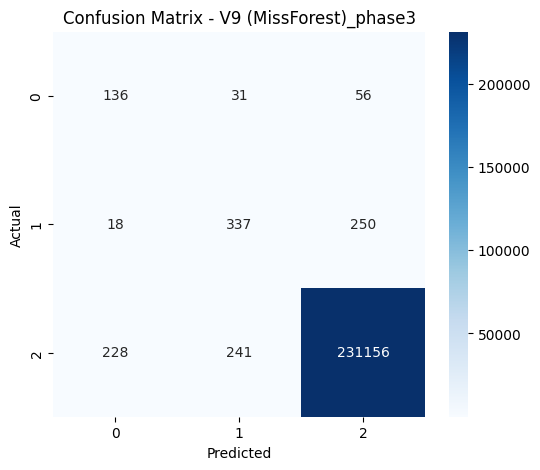

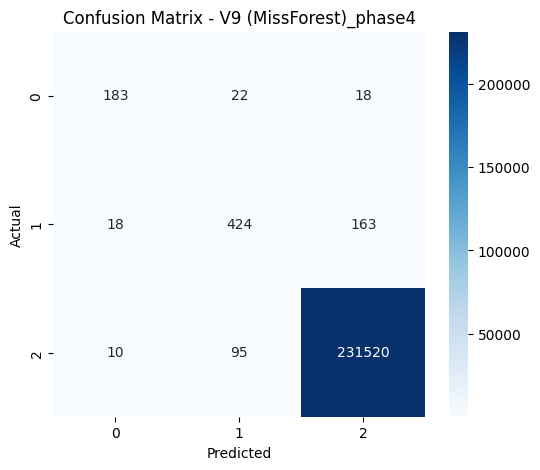

In [ ]:
df_v9 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V9 (MissForest)"
)

df_v9

In [ ]:
df_v9.to_csv("results_v9.csv", index=False)

## V10 (MissForest CDSMOTE)


#####
Version: V10 (MissForest CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0399
Epoch 2: loss = 0.0162
Epoch 3: loss = 0.0127
Epoch 4: loss = 0.0110
Epoch 5: loss = 0.0099
Epoch 6: loss = 0.0093
Epoch 7: loss = 0.0088
Epoch 8: loss = 0.0085
Epoch 9: loss = 0.0081
Epoch 10: loss = 0.0080
Epoch 11: loss = 0.0078
Epoch 12: loss = 0.0076
Epoch 13: loss = 0.0075
Epoch 14: loss = 0.0074
Epoch 15: loss = 0.0073
Epoch 16: loss = 0.0072
Epoch 17: loss = 0.0071
Epoch 18: loss = 0.0070
Epoch 19: loss = 0.0070
Epoch 20: loss = 0.0069
Epoch 21: loss = 0.0068
Epoch 22: loss = 0.0068
Epoch 23: loss = 0.0068
Epoch 24: loss = 0.0067
Epoch 25: loss = 0.0067
Epoch 26: loss = 0.0066
Epoch 27: loss = 0.0066
Epoch 28: loss 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V10 (MissForest CDSMOTE),1,4870.325198,0.156219,0.996490,0.351271,0.665496,0.993899,0.351271,0.996490,0.366790,0.994784,0.000000,0.120289,0.028509,1.000000,0.053812,0.102128,0.231973,0.000000,0.000000,0.000000,0.000000,0.996489,1.000000,0.998242,0.120386
1,V10 (MissForest CDSMOTE),2,4870.325198,0.156260,0.996567,0.377782,0.949843,0.996459,0.377782,0.996567,0.410187,0.994967,0.162143,0.190945,0.076211,0.852941,0.130045,0.225681,0.360613,1.000000,0.003306,0.006590,0.057496,0.996588,0.999996,0.998289,0.205598
2,V10 (MissForest CDSMOTE),3,4870.325198,0.156286,0.996266,0.599958,0.636226,0.995804,0.599958,0.996266,0.583493,0.995806,0.580901,0.383734,0.376918,0.390313,0.614350,0.477352,0.783443,0.520737,0.186777,0.274939,0.432080,0.997628,0.998748,0.998188,0.579075
3,V10 (MissForest CDSMOTE),4,4870.325198,0.155998,0.997079,0.866681,0.684853,0.997822,0.866681,0.997079,0.755502,0.997367,0.901669,0.675165,0.663736,0.488251,0.838565,0.617162,0.915345,0.566871,0.763636,0.650704,0.873197,0.999438,0.997841,0.998639,0.917156


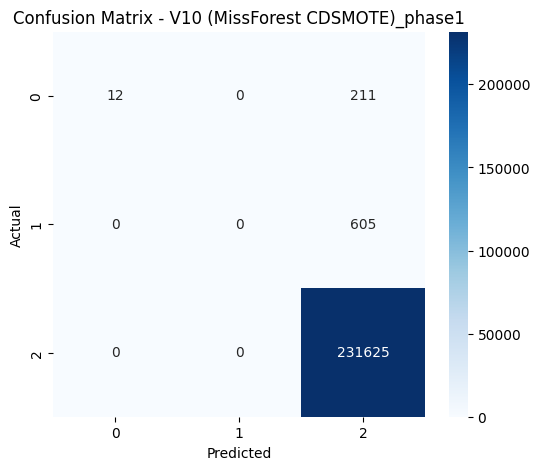

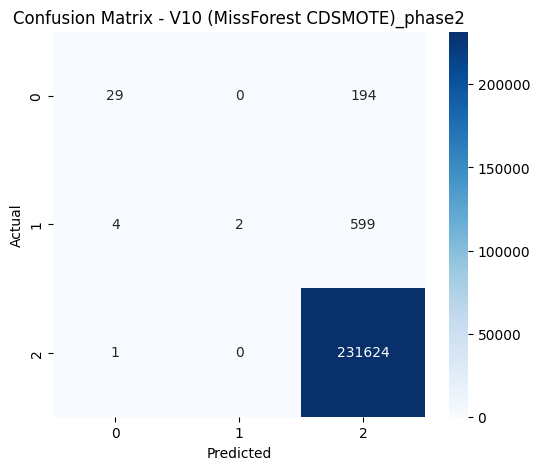

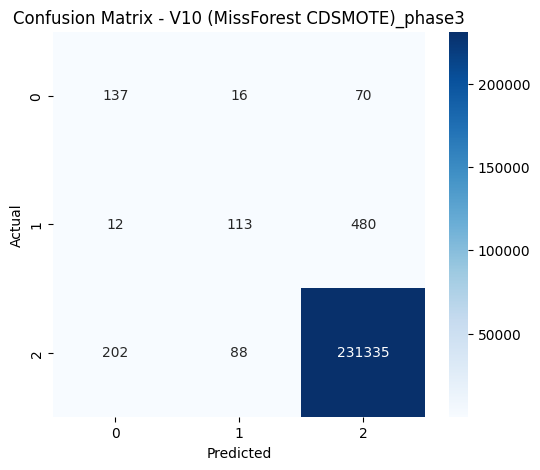

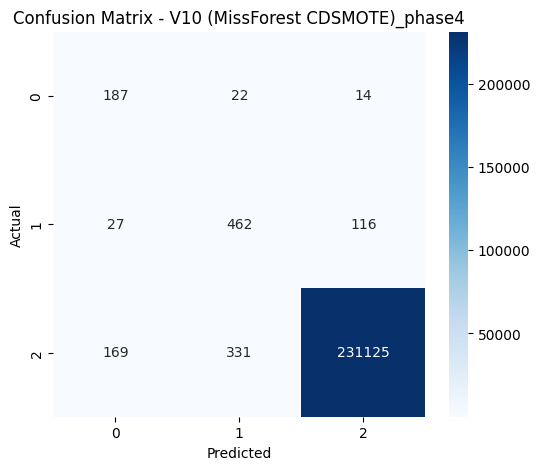

In [ ]:
df_v10 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V10 (MissForest CDSMOTE)"
)

df_v10

In [ ]:
df_v10.to_csv("results_v10.csv", index=False)

## V11 (MissForest SASMOTE)


#####
Version: V11 (MissForest SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0399
Epoch 2: loss = 0.0161
Epoch 3: loss = 0.0127
Epoch 4: loss = 0.0110
Epoch 5: loss = 0.0100
Epoch 6: loss = 0.0093
Epoch 7: loss = 0.0088
Epoch 8: loss = 0.0085
Epoch 9: loss = 0.0082
Epoch 10: loss = 0.0080
Epoch 11: loss = 0.0078
Epoch 12: loss = 0.0076
Epoch 13: loss = 0.0075
Epoch 14: loss = 0.0074
Epoch 15: loss = 0.0073
Epoch 16: loss = 0.0072
Epoch 17: loss = 0.0072
Epoch 18: loss = 0.0071
Epoch 19: loss = 0.0070
Epoch 20: loss = 0.0069
Epoch 21: loss = 0.0068
Epoch 22: loss = 0.0068
Epoch 23: loss = 0.0068
Epoch 24: loss = 0.0067
Epoch 25: loss = 0.0067
Epoch 26: loss = 0.0066
Epoch 27: loss = 0.0066
Epoch 28: loss 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V11 (MissForest SASMOTE),1,4765.958943,0.156374,0.996520,0.361734,0.665506,0.993929,0.361734,0.996520,0.385094,0.994852,0.000000,0.151363,0.044767,1.000000,0.085202,0.157025,0.291893,0.000000,0.000000,0.000000,0.000000,0.996519,1.000000,0.998257,0.151482
1,V11 (MissForest SASMOTE),2,4765.958943,0.156172,0.996679,0.411927,0.874211,0.995868,0.411927,0.996679,0.460708,0.995199,0.241296,0.260383,0.134232,0.925926,0.224215,0.361011,0.473510,0.700000,0.011570,0.022764,0.107564,0.996708,0.999996,0.998349,0.275838
2,V11 (MissForest SASMOTE),3,4765.958943,0.156371,0.996339,0.582634,0.691356,0.996013,0.582634,0.996339,0.624905,0.996138,0.620774,0.429368,0.426608,0.694030,0.417040,0.521008,0.645730,0.382129,0.332231,0.355438,0.575991,0.997908,0.998631,0.998269,0.643183
3,V11 (MissForest SASMOTE),4,4765.958943,0.156166,0.997453,0.881966,0.707744,0.998054,0.881966,0.997453,0.775599,0.997683,0.913696,0.708435,0.699121,0.497409,0.860987,0.630542,0.927506,0.626316,0.786777,0.697436,0.886461,0.999507,0.998135,0.998821,0.927745


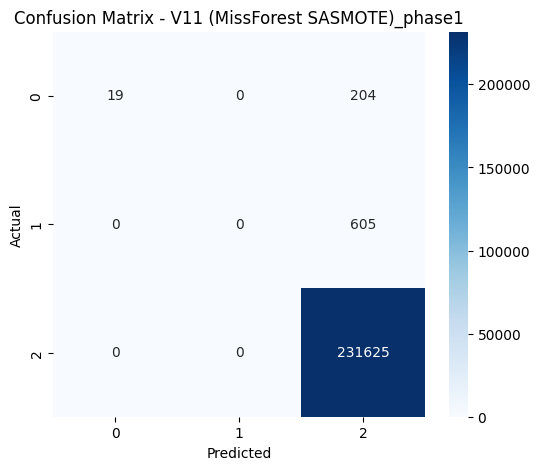

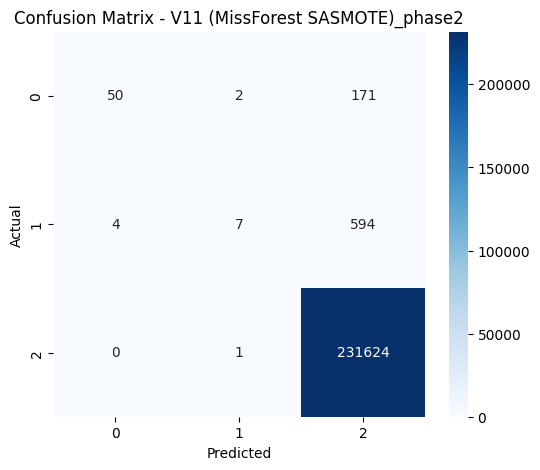

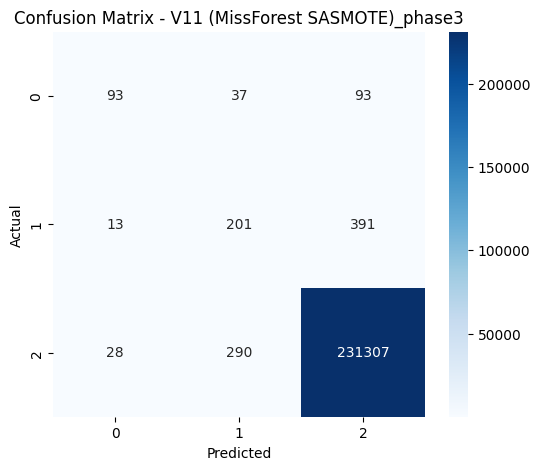

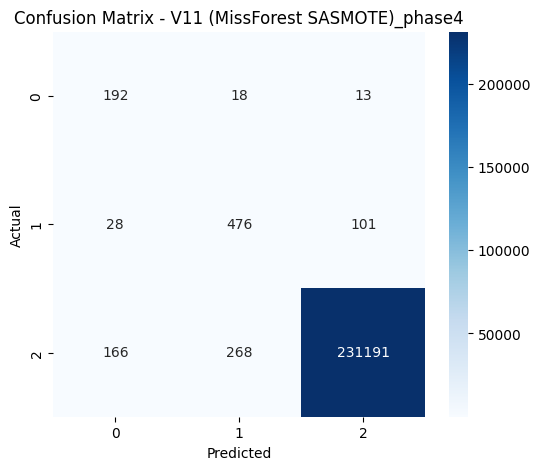

In [ ]:
df_v11 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V11 (MissForest SASMOTE)"
)

df_v11

In [ ]:
df_v11.to_csv("results_v11.csv", index=False)

## V12 (MissForest RadiusSMOTE)


#####
Version: V12 (MissForest RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0337
Epoch 2: loss = 0.0127
Epoch 3: loss = 0.0102
Epoch 4: loss = 0.0090
Epoch 5: loss = 0.0083
Epoch 6: loss = 0.0079
Epoch 7: loss = 0.0075
Epoch 8: loss = 0.0072
Epoch 9: loss = 0.0070
Epoch 10: loss = 0.0068
Epoch 11: loss = 0.0067
Epoch 12: loss = 0.0066
Epoch 13: loss = 0.0064
Epoch 14: loss = 0.0064
Epoch 15: loss = 0.0063
Epoch 16: loss = 0.0062
Epoch 17: loss = 0.0061
Epoch 18: loss = 0.0061
Epoch 19: loss = 0.0060
Epoch 20: loss = 0.0060
Epoch 21: loss = 0.0059
Epoch 22: loss = 0.0059
Epoch 23: loss = 0.0058
Epoch 24: loss = 0.0058
Epoch 25: loss = 0.0058
Epoch 26: loss = 0.0057
Epoch 27: loss = 0.0057
Epoch 2

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V12 (MissForest RadiusSMOTE),1,4519.331994,0.156049,0.834534,0.631265,0.365419,0.996110,0.631265,0.834534,0.351907,0.906899,0.693924,0.102582,0.026891,0.083333,0.210762,0.119441,0.458577,0.013369,0.847934,0.026323,0.842300,0.999556,0.835100,0.909957,0.865079
1,V12 (MissForest RadiusSMOTE),2,4519.331994,0.155998,0.662775,0.569458,0.416773,0.996281,0.569458,0.662775,0.326833,0.794314,0.603439,0.065656,0.010874,0.243697,0.130045,0.169591,0.360547,0.007031,0.915702,0.013956,0.778911,0.999590,0.662627,0.796954,0.782438
2,V12 (MissForest RadiusSMOTE),3,4519.331994,0.155842,0.915759,0.708040,0.451809,0.996239,0.708040,0.915759,0.453125,0.953229,0.779820,0.149818,0.056192,0.330739,0.381166,0.354167,0.617158,0.025270,0.826446,0.049041,0.870459,0.999416,0.916507,0.956168,0.882753
3,V12 (MissForest RadiusSMOTE),4,4519.331994,0.155770,0.997432,0.826265,0.709521,0.997835,0.826265,0.997432,0.759167,0.997599,0.873532,0.684891,0.680250,0.537500,0.771300,0.633517,0.877957,0.591724,0.709091,0.645113,0.841538,0.999339,0.998403,0.998870,0.902172


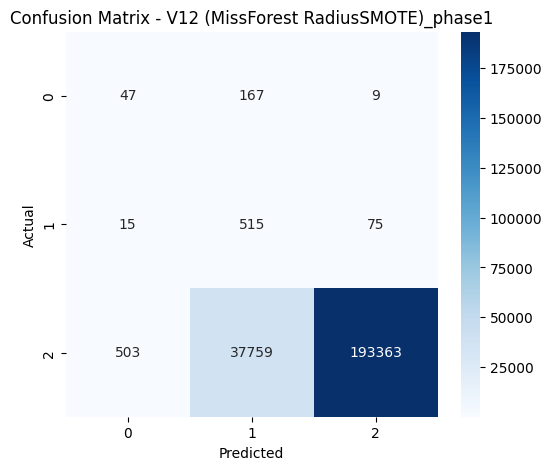

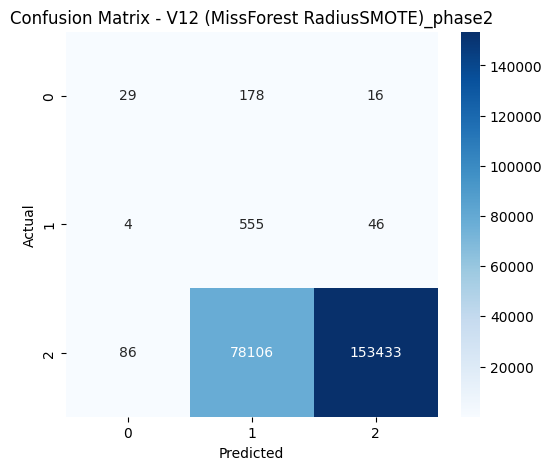

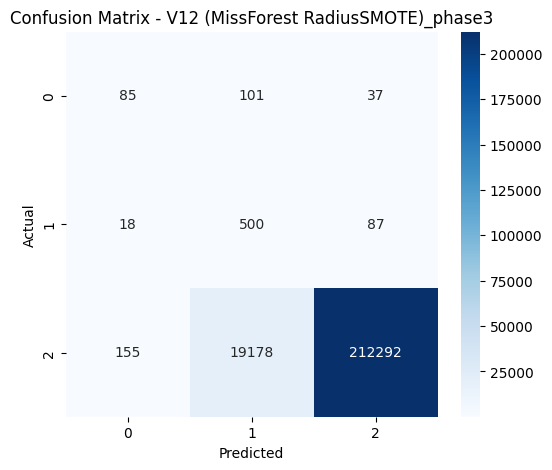

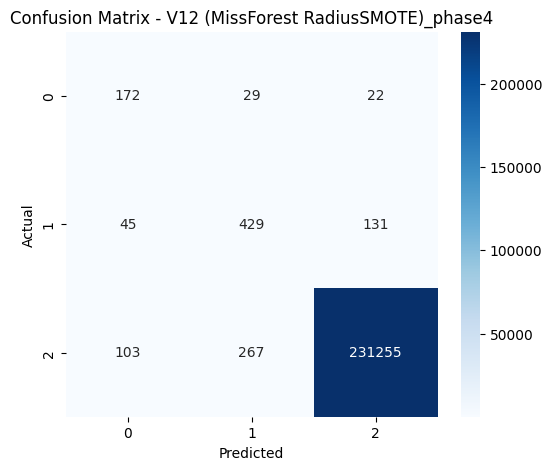

In [ ]:
df_v12 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V12 (MissForest RadiusSMOTE)"
)

df_v12

In [ ]:
df_v12.to_csv("results_v12.csv", index=False)